In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
TRAIN_PATH = '../data/train.csv'

full_data = pd.read_csv(TRAIN_PATH)

full_data

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0
...,...,...,...
390346,77801,185970,5.0
390347,77801,185971,5.0
390348,77802,44671,10.0
390349,77803,154450,10.0


In [11]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(full_data, test_size=0.2, random_state=42)

len(train_data), len(test_data)

(312280, 78071)

In [6]:
from utils.analysis import DatasetProfiler

profiler = DatasetProfiler(user_col='user', item_col='item', rating_col='rating')

profiler.fit(train_data)
profiler.print_report()

RECOMMENDER DATASET REPORT

[1] DATASET SUMMARY
  - n_interactions: 312280
  - n_users: 64356
  - n_items: 146015
  - density: 0.0
  - sparsity: 1.0
  - avg_interactions_per_user: 4.8524
  - avg_interactions_per_item: 2.1387
  - rating_mean: 7.6018
  - rating_std: 1.8424
  - rating_min: 1.0
  - rating_max: 10.0
  - rating_median: 8.0

[2] USER PROFILE
  - n_users: 64356
  - min_interactions: 1
  - max_interactions: 4794
  - mean_interactions: 4.8524
  - median_interactions: 1.0
  - std_interactions: 29.5096
  - p25_interactions: 1.0
  - p75_interactions: 3.0
  - p90_interactions: 8.0
  - p95_interactions: 16.0
  - p99_interactions: 62.0
  - share_with_1_interaction: 0.589
  - share_with_le_2_interactions: 0.7207
  - share_with_le_5_interactions: 0.8569
  - share_with_le_10_interactions: 0.9219
  - share_with_ge_10_interactions: 0.0856
  - share_with_ge_20_interactions: 0.0414
  - head_1pct_interaction_share: 0.2959
  - head_5pct_interaction_share: 0.5438
  - head_10pct_interaction_shar

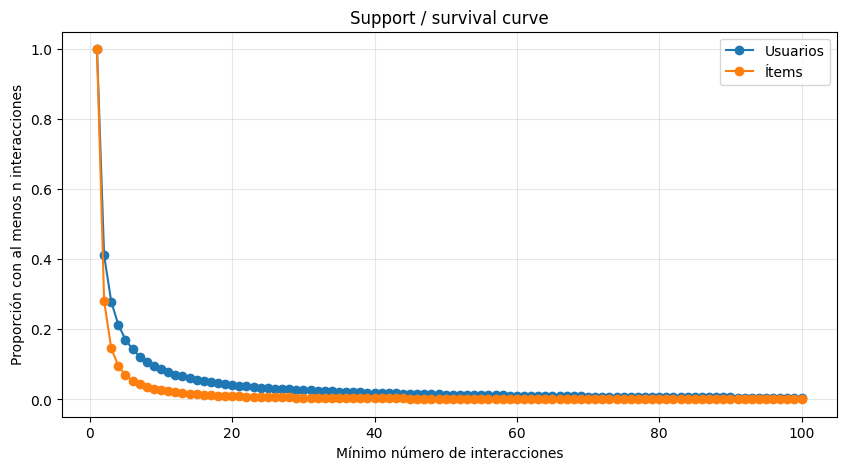

In [7]:
profiler.plot_support_curves()

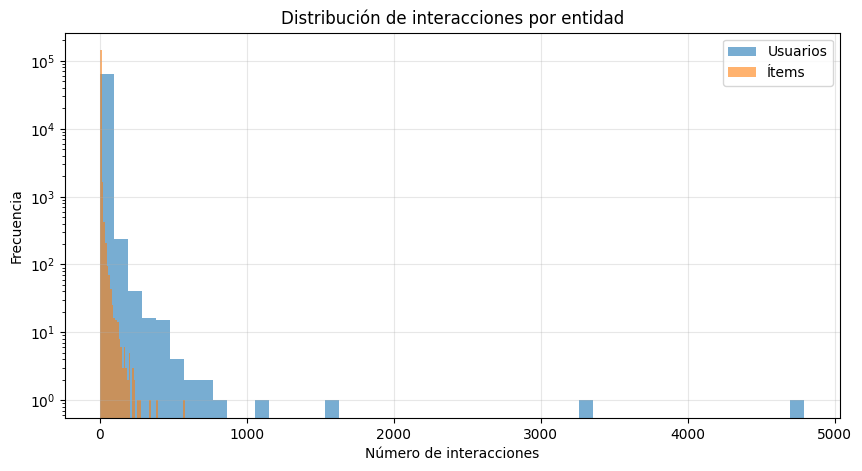

In [8]:
profiler.plot_count_distributions()

In [11]:
TEST_PATH = '../data/test.csv'

test_data = pd.read_csv(TEST_PATH)

test_data = test_data[['user', 'item']]

test_data = pd.concat([test_data, pd.DataFrame({'rating': np.nan}, index=test_data.index)], axis=1)

test_data

,user,item,rating
0,8117,268,NaN
1,10512,24393,NaN
2,534,1334,NaN
3,10984,6550,NaN
4,9093,22128,NaN
...,...,...,...
43315,534,1751,NaN
43316,1150,5467,NaN
43317,10184,8805,NaN
43318,7531,11566,NaN


In [12]:
test_profiler = DatasetProfiler(user_col='user', item_col='item', rating_col='rating')

test_profiler.fit(test_data)
test_profiler.print_report()

RECOMMENDER DATASET REPORT

[1] DATASET SUMMARY
  - n_interactions: 43320
  - n_users: 11426
  - n_items: 25697
  - density: 0.0001
  - sparsity: 0.9999
  - avg_interactions_per_user: 3.7914
  - avg_interactions_per_item: 1.6858
  - rating_mean: nan
  - rating_std: nan
  - rating_min: nan
  - rating_max: nan
  - rating_median: nan

[2] USER PROFILE
  - n_users: 11426
  - min_interactions: 1
  - max_interactions: 2532
  - mean_interactions: 3.7914
  - median_interactions: 1.0
  - std_interactions: 30.6432
  - p25_interactions: 1.0
  - p75_interactions: 2.0
  - p90_interactions: 6.0
  - p95_interactions: 11.0
  - p99_interactions: 38.0
  - share_with_1_interaction: 0.6186
  - share_with_le_2_interactions: 0.7634
  - share_with_le_5_interactions: 0.8932
  - share_with_le_10_interactions: 0.9451
  - share_with_ge_10_interactions: 0.0597
  - share_with_ge_20_interactions: 0.0256
  - head_1pct_interaction_share: 0.3133
  - head_5pct_interaction_share: 0.5178
  - head_10pct_interaction_share:

c:\Users\mario\OneDrive\Documentos\UPM\Master_Data\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\mario\OneDrive\Documentos\UPM\Master_Data\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


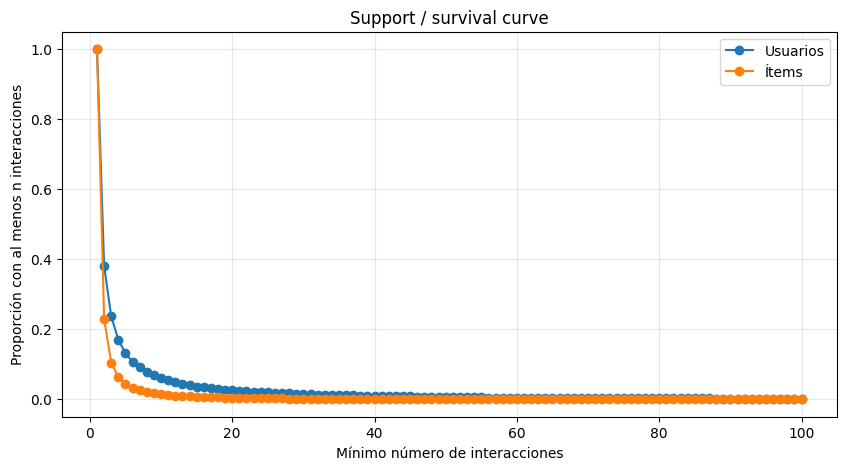

In [13]:
test_profiler.plot_support_curves()

In [60]:
from model.baseline import SurpriseBaselineOnlyModel

baseline_model = SurpriseBaselineOnlyModel()
baseline_model.fit(train_data)

baseline_predictions = baseline_model.predict_df(test_data, round_predictions=True)

mae_baseline = np.mean(np.abs(baseline_predictions['prediction'] - test_data['rating']))

print(f'MAE for Baseline Model: {mae_baseline}')

MAE for Baseline Model: 1.2535768723341574


In [61]:
from utils.split import FrequencyBandSplitter, FrequencyBandEvaluator

splitter = FrequencyBandSplitter(mode="threshold", low_threshold=1, high_threshold=10)
splitter.fit(full_data)
evaluator = FrequencyBandEvaluator(splitter)

evaluator.evaluate(baseline_model, test_data)

,band,n_rows,rmse,mae
0,high,25008,1.589139,1.235518
1,low,24105,1.700726,1.316476
2,mid,28958,1.655808,1.282160


In [62]:
from model.PMF import SurpriseNMFModel

nmf = SurpriseNMFModel(n_factors=15, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)
nmf.fit(train_data)

nmf_predictions = nmf.predict_df(test_data, round_predictions=True)
mae_nmf = np.mean(np.abs(nmf_predictions['prediction'] - test_data['rating']))
print(f'MAE for NMF Model: {mae_nmf}')

evaluator.evaluate(nmf, test_data)

MAE for NMF Model: 1.228612416902563


,band,n_rows,rmse,mae
0,high,25008,1.582970,1.218163
1,low,24105,1.669804,1.275928
2,mid,28958,1.642093,1.260254


In [63]:
from ensemble.ensemble import RatingEnsemble

ensemble = RatingEnsemble(models=[baseline_model, nmf], weights=[0.5, 0.5])
ensemble_predictions = ensemble.predict_df(test_data, round_predictions=True)
mae_ensemble = np.mean(np.abs(ensemble_predictions['prediction'] - test_data['rating']))
print(f'MAE for Ensemble Model: {mae_ensemble}')

evaluator.evaluate(ensemble, test_data)

MAE for Ensemble Model: 1.239128485609253


,band,n_rows,rmse,mae
0,high,25008,1.580414,1.223126
1,low,24105,1.680405,1.293127
2,mid,28958,1.643865,1.267816


In [64]:
from utils.predict import Predictor
baseline_model = SurpriseBaselineOnlyModel()
baseline_model.fit(full_data)

nmf = SurpriseNMFModel(n_factors=15, n_epochs=40, biased=True, verbose=False, reg_pu=0.5, reg_qi=0.5, init_low=0.001, init_high=0.001, reg_bu=0.0002, reg_bi=0.0002)
nmf.fit(full_data)

ensemble = RatingEnsemble(models=[baseline_model, nmf], weights=[0.5, 0.5])

predictor = Predictor(test_path='../data/test.csv', save_path='../data/solution_ensemble.csv', round_predictions=True)
predictor.predict(ensemble)

Predictions saved to ../data/solution_ensemble.csv. Number of errors: 0


,ID,rating
0,0,8.0
1,1,8.0
2,2,7.0
3,3,8.0
4,4,7.0
...,...,...
43315,43315,7.0
43316,43316,9.0
43317,43317,8.0
43318,43318,7.0


In [ ]:
TRAIN_PATH = '../data/train.csv'

full_data = pd.read_csv(TRAIN_PATH)

train_data, test_data = train_test_split(full_data, test_size=0.1, random_state=42)

train_data